Found 4 csv files.
Processing: CTDNE
Processing: LAGO
Processing: Louvain
Processing: our_method
    mu     p  ami_mean       ami_std  ami_n  ari_mean   ari_std  ari_n  \
0  0.0  0.80  0.060307  1.721670e-02      5  0.058603  0.023645      5   
1  0.0  0.85  0.080469  1.916779e-02      5  0.079806  0.031612      5   
2  0.0  0.90  0.161841  2.801740e-02      5  0.153682  0.040817      5   
3  0.0  0.95  0.291836  1.993986e-02      5  0.302764  0.027813      5   
4  0.0  1.00  1.000000  1.110223e-16      5  1.000000  0.000000      5   

        ami_sem   ari_sem algorithm  
0  7.699542e-03  0.010574     CTDNE  
1  8.572097e-03  0.014137     CTDNE  
2  1.252976e-02  0.018254     CTDNE  
3  8.917378e-03  0.012438     CTDNE  
4  4.965068e-17  0.000000     CTDNE  


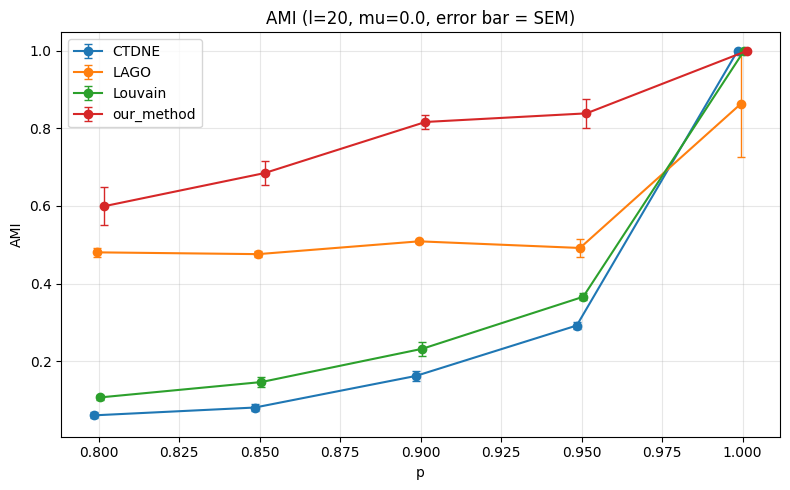

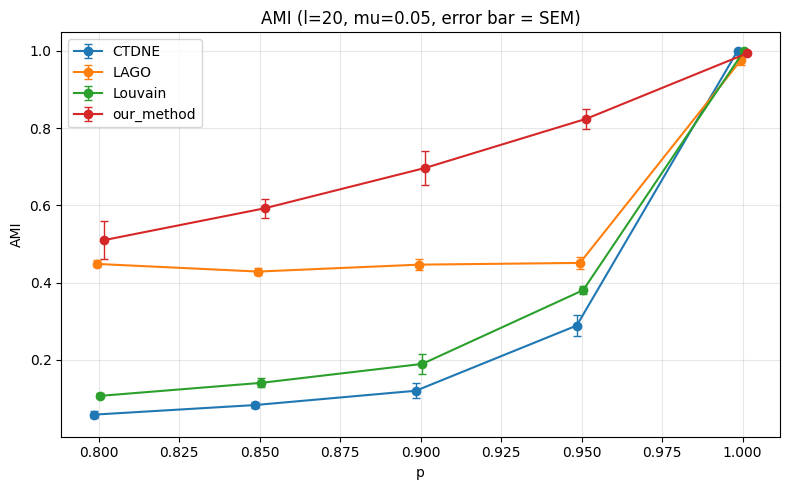

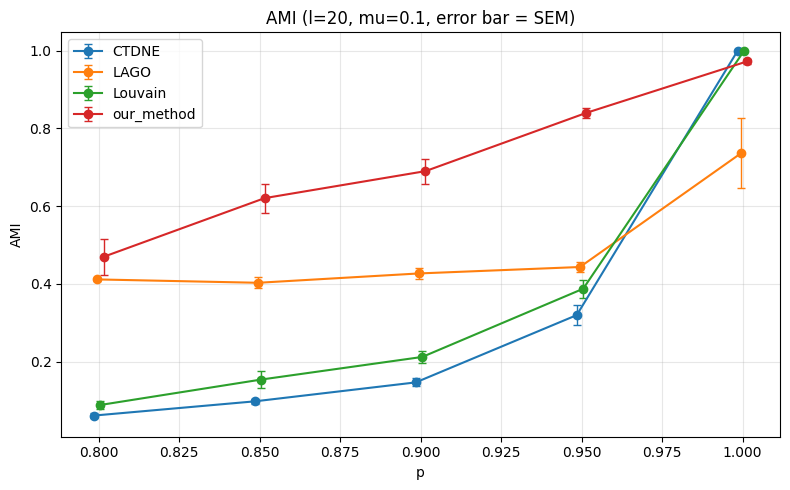

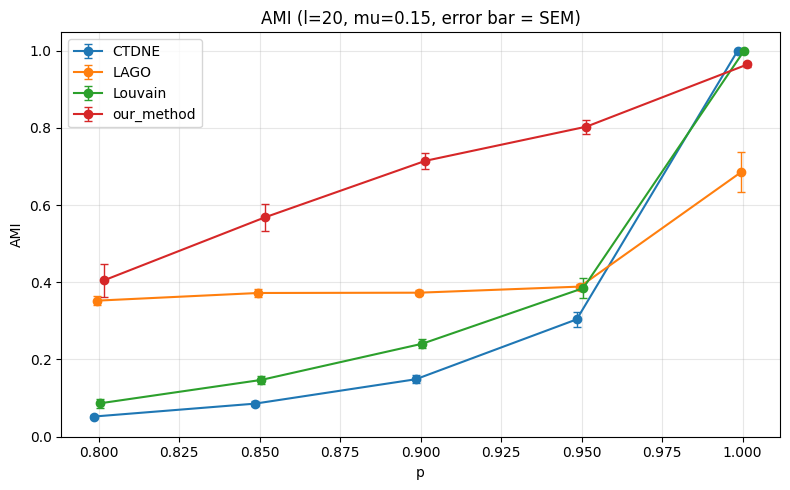

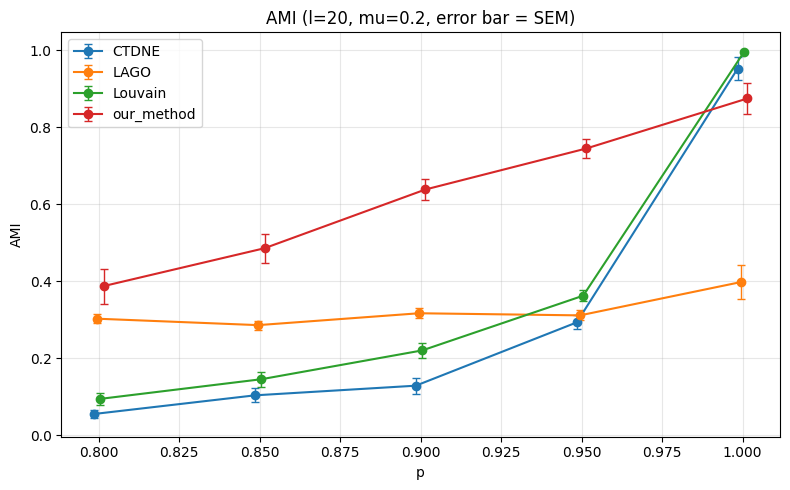

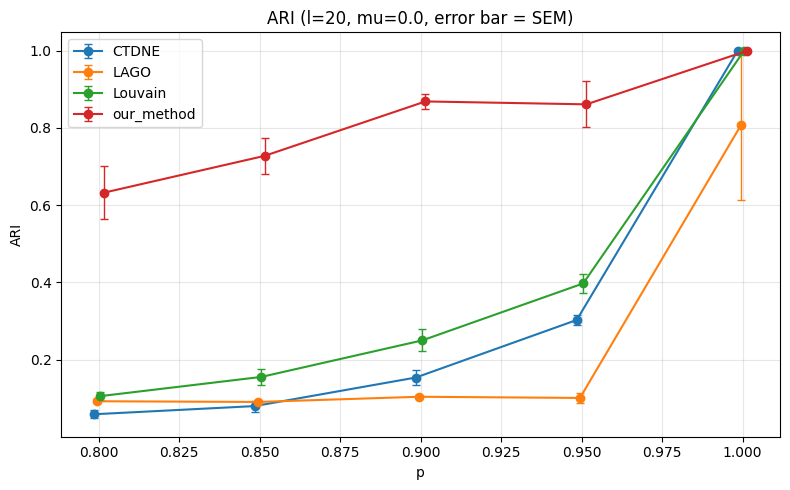

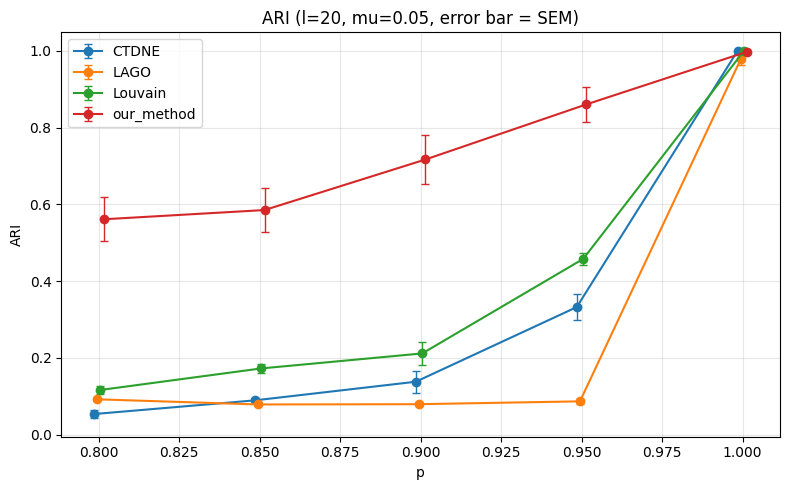

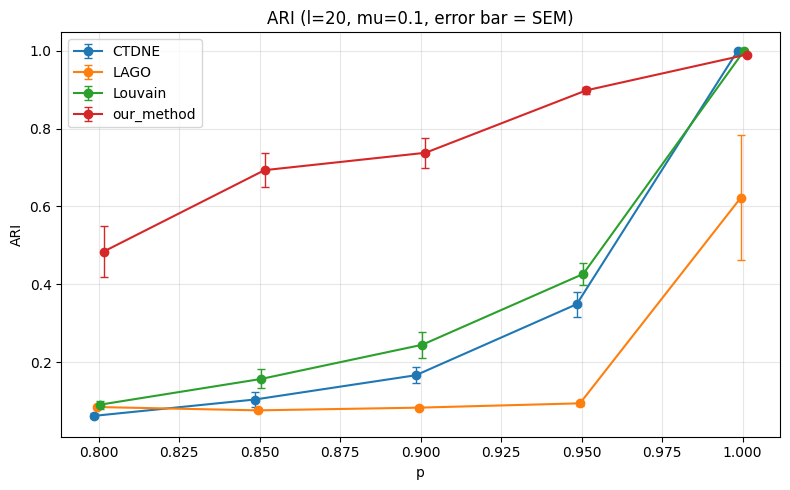

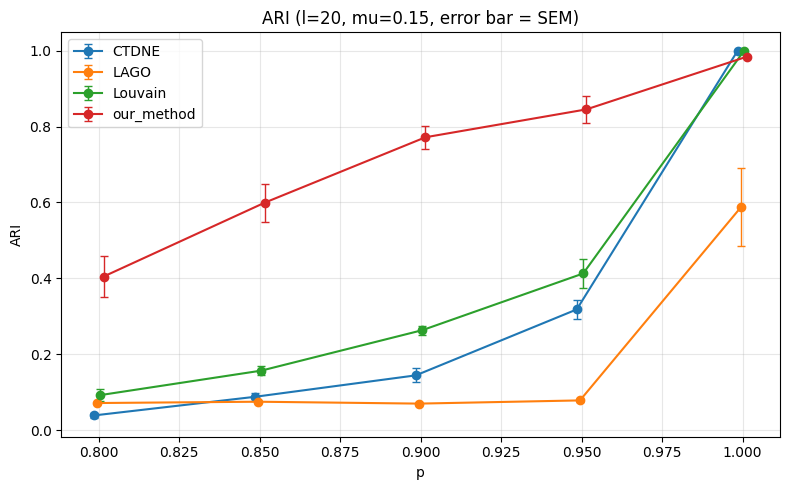

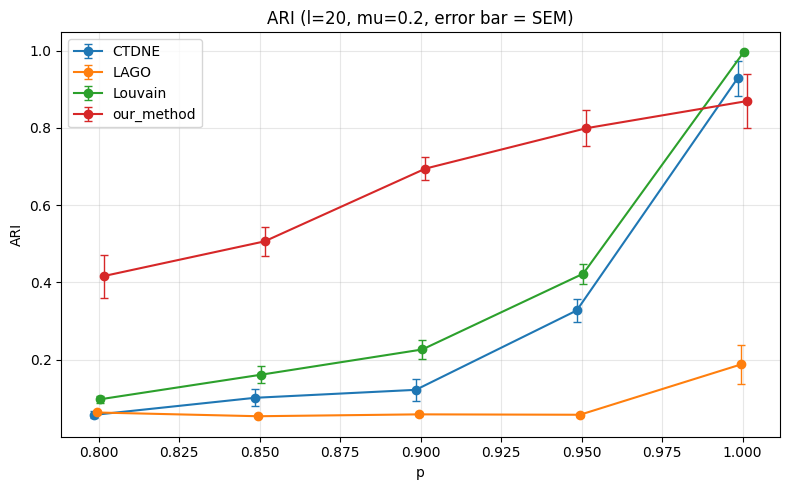

In [28]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "results"
TARGET_L = 20

# 文件名/数据名格式示例: p1.0_mu0.0_l5_1.csv
pattern = r"p([0-9.]+)_mu([0-9.]+)_l(\d+)_(\d+)"

all_grouped = []

csv_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv")))
print(f"Found {len(csv_files)} csv files.")

for file_path in csv_files:
    algo_name = os.path.splitext(os.path.basename(file_path))[0]
    print(f"Processing: {algo_name}")

    df = pd.read_csv(file_path)

    required_cols = {"data_name", "ami", "ari"}
    if not required_cols.issubset(df.columns):
        print(f"Skip {algo_name}: missing columns {required_cols - set(df.columns)}")
        continue

    df = df[["data_name", "ami", "ari"]].copy()

    parsed = df["data_name"].str.extract(pattern)
    parsed.columns = ["p", "mu", "l", "index"]

    valid_mask = parsed.notna().all(axis=1)
    df = df.loc[valid_mask].copy()
    parsed = parsed.loc[valid_mask].copy()

    df["p"] = parsed["p"].astype(float)
    df["mu"] = parsed["mu"].astype(float)
    df["l"] = parsed["l"].astype(int)
    df["index"] = parsed["index"].astype(int)

    # 只保留指定层数
    df = df[df["l"] == TARGET_L].copy()
    if df.empty:
        print(f"Skip {algo_name}: no l={TARGET_L} data")
        continue

    grouped = (
        df.groupby(["mu", "p"])
          .agg(
              ami_mean=("ami", "mean"),
              ami_std=("ami", "std"),
              ami_n=("ami", "count"),
              ari_mean=("ari", "mean"),
              ari_std=("ari", "std"),
              ari_n=("ari", "count"),
          )
          .reset_index()
    )

    # 标准误 SEM = std / sqrt(n)
    grouped["ami_sem"] = grouped["ami_std"] / np.sqrt(grouped["ami_n"])
    grouped["ari_sem"] = grouped["ari_std"] / np.sqrt(grouped["ari_n"])

    # 如果某组只有1个样本，std会是NaN，这里填成0
    grouped["ami_sem"] = grouped["ami_sem"].fillna(0)
    grouped["ari_sem"] = grouped["ari_sem"].fillna(0)

    grouped["algorithm"] = algo_name
    all_grouped.append(grouped)

if not all_grouped:
    raise ValueError(f"No valid CSV data found in {RESULTS_DIR}/ for l={TARGET_L}")

all_grouped_df = pd.concat(all_grouped, ignore_index=True)

print(all_grouped_df.head())


def plot_metric(all_grouped_df, metric="ami"):
    """
    metric: 'ami' or 'ari'
    使用 mean ± SEM 绘图
    """
    mu_list = sorted(all_grouped_df["mu"].unique())

    for mu in mu_list:
        plt.figure(figsize=(8, 5))

        sub_mu = all_grouped_df[all_grouped_df["mu"] == mu]
        algos = sorted(sub_mu["algorithm"].unique())

        n = len(algos)
        offsets = [(i - (n - 1) / 2) * 0.001 for i in range(n)]

        for i, algo in enumerate(algos):
            sub_algo = sub_mu[sub_mu["algorithm"] == algo].sort_values("p")

            x = sub_algo["p"].to_numpy() + offsets[i]
            y = sub_algo[f"{metric}_mean"].to_numpy()
            e = sub_algo[f"{metric}_sem"].to_numpy()

            plt.errorbar(
                x,
                y,
                yerr=e,
                marker="o",
                capsize=3,
                elinewidth=1,
                linewidth=1.5,
                label=algo
            )

        plt.xlabel("p")
        plt.ylabel(metric.upper())
        plt.title(f"{metric.upper()} (l={TARGET_L}, mu={mu}, error bar = SEM)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# 第一张图：AMI
plot_metric(all_grouped_df, metric="ami")

# 第二张图：ARI
plot_metric(all_grouped_df, metric="ari")

Found 4 csv files.
Processing: CTDNE
Processing: LAGO
Processing: Louvain
Processing: our_method

Filtered data:
            data_name       ami       ari algorithm    p   mu  layer  idx
160  p0.8_mu0.1_l10_1  0.160478  0.162555     CTDNE  0.8  0.1     10    1
161  p0.8_mu0.1_l10_2  0.165950  0.210898     CTDNE  0.8  0.1     10    2
162  p0.8_mu0.1_l10_3  0.172828  0.283019     CTDNE  0.8  0.1     10    3
163  p0.8_mu0.1_l10_4  0.163091  0.207843     CTDNE  0.8  0.1     10    4
164  p0.8_mu0.1_l10_5  0.144544  0.132785     CTDNE  0.8  0.1     10    5

AMI aggregated:
     algorithm    p   mu  layer      mean  count       std     error
0        CTDNE  0.8  0.1      5  0.277836      5  0.057597  0.025758
1        CTDNE  0.8  0.1     10  0.161378      5  0.010478  0.004686
2        CTDNE  0.8  0.1     15  0.082336      5  0.028354  0.012680
3        CTDNE  0.8  0.1     20  0.061575      5  0.015970  0.007142
4        CTDNE  0.8  0.2      5  0.291981      5  0.076369  0.034153
..         .

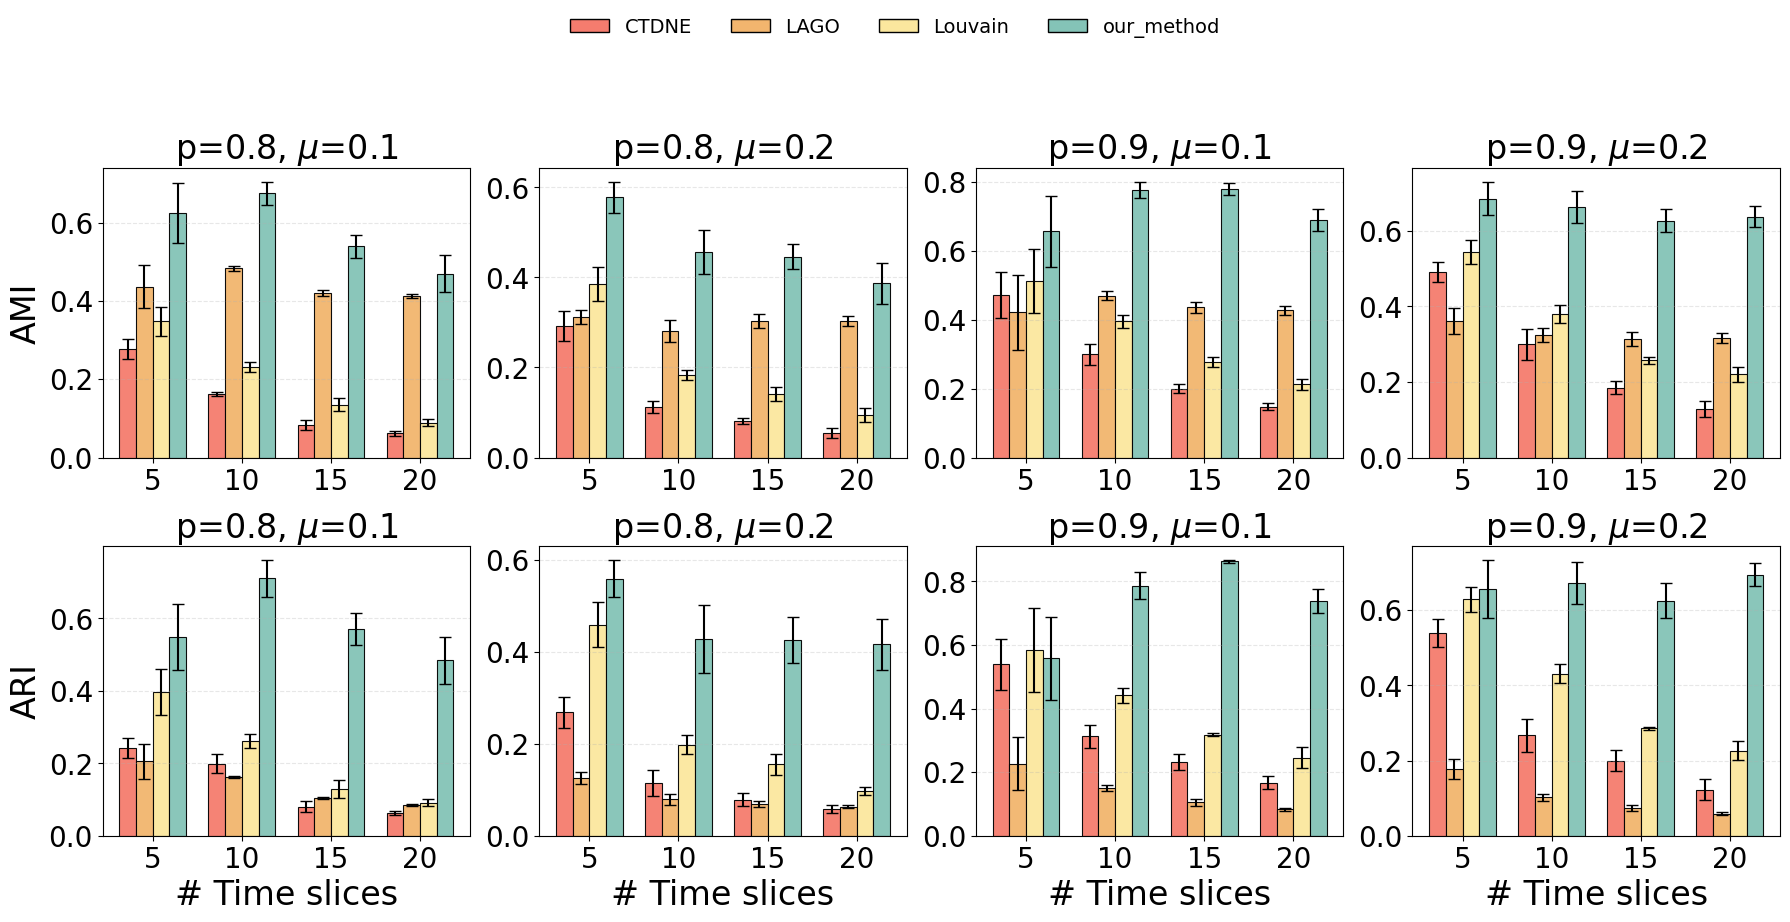

Saved figure to: ./plots/ami_ari_grid_sem_p0.8_0.9_mu0.1_0.2.png


In [31]:
import os
import re
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

INPUT_DIR = "results/"
OUTPUT_DIR = "."

# ========= 指定要绘制的 p 和 mu =========
TARGET_P = [0.8, 0.9]
TARGET_MU = [0.1, 0.2]

# ========= error bar 类型：固定为 SEM =========
ERROR_TYPE = "sem"

SHOW_VALUE = False

TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 24
TICK_FONTSIZE = 20
LEGEND_FONTSIZE = 14
VALUE_FONTSIZE = 9

# ========= 柱状图宽度配置 =========
GROUP_WIDTH = 0.75
BAR_WIDTH = None

# ========= 颜色配置 =========
COLOR_LIST = [
    "#f57c6e",
    "#f2b56e",
    "#fbe79e",
    "#84c3b7",
    "#88d7da",
    "#71b8ed",
    "#b8aeea",
    "#f2a8da",
]

# data_name 示例: p0.8_mu0.2_l5_1.csv
PATTERN = re.compile(
    r"p(?P<p>[0-9.]+)_mu(?P<mu>[0-9.]+)_l(?P<layer>\d+)_(?P<idx>\d+)(?:\.csv)?$"
)


def compute_error(x, error_type="sem"):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    std = np.std(x, ddof=1)
    if error_type == "std":
        return std
    elif error_type == "sem":
        return std / math.sqrt(len(x))
    else:
        raise ValueError(f"Unsupported ERROR_TYPE: {error_type}")


def load_all_results(input_dir):
    all_dfs = []

    csv_files = sorted(glob.glob(os.path.join(input_dir, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No csv files found in {input_dir}")

    print(f"Found {len(csv_files)} csv files.")

    for file_path in csv_files:
        algo_name = os.path.splitext(os.path.basename(file_path))[0]
        print(f"Processing: {algo_name}")

        df = pd.read_csv(file_path)

        required_cols = {"data_name", "ami", "ari"}
        if not required_cols.issubset(df.columns):
            print(f"Skip {algo_name}: missing columns {required_cols - set(df.columns)}")
            continue

        tmp = df[["data_name", "ami", "ari"]].copy()
        tmp["algorithm"] = algo_name

        parsed = tmp["data_name"].astype(str).str.extract(PATTERN)
        valid_mask = parsed.notna().all(axis=1)

        if valid_mask.sum() == 0:
            print(f"Skip {algo_name}: no valid data_name matched pattern")
            continue

        tmp = tmp.loc[valid_mask].copy()
        parsed = parsed.loc[valid_mask].copy()

        tmp["p"] = parsed["p"].astype(float)
        tmp["mu"] = parsed["mu"].astype(float)
        tmp["layer"] = parsed["layer"].astype(int)
        tmp["idx"] = parsed["idx"].astype(int)

        all_dfs.append(tmp)

    if not all_dfs:
        raise ValueError("No valid data loaded.")

    full_df = pd.concat(all_dfs, ignore_index=True)
    return full_df


def aggregate_metric(df, metric_name):
    grouped = (
        df.groupby(["algorithm", "p", "mu", "layer"])[metric_name]
        .agg(
            mean="mean",
            count="count",
            std=lambda x: np.std(x, ddof=1) if len(x) > 1 else 0.0,
            error=lambda x: compute_error(x, ERROR_TYPE),
        )
        .reset_index()
    )
    return grouped


def plot_all_subplots(ami_grouped, ari_grouped, target_p, target_mu, output_dir):
    target_pairs = sorted(
        [(p, mu) for p in target_p for mu in target_mu],
        key=lambda x: (x[0], x[1])
    )

    all_algorithms = sorted(
        set(ami_grouped["algorithm"].unique()).union(set(ari_grouped["algorithm"].unique()))
    )
    n_algos = len(all_algorithms)

    n_cols = len(target_pairs)
    n_rows = 2

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 9),
        squeeze=False
    )

    if BAR_WIDTH is None:
        bar_width = GROUP_WIDTH / max(n_algos, 1)
    else:
        bar_width = BAR_WIDTH

    total_width = bar_width * n_algos

    metric_info = [
        ("ami", ami_grouped, 0),
        ("ari", ari_grouped, 1),
    ]

    for col_idx, (p_val, mu_val) in enumerate(target_pairs):
        for metric_name, grouped_df, row_idx in metric_info:
            ax = axes[row_idx, col_idx]

            sub_df = grouped_df[
                (grouped_df["p"] == p_val) &
                (grouped_df["mu"] == mu_val)
            ].copy()

            if sub_df.empty:
                ax.set_visible(False)
                continue

            layers = sorted(sub_df["layer"].unique())
            x = np.arange(len(layers))

            for i, algo in enumerate(all_algorithms):
                algo_sub = sub_df[sub_df["algorithm"] == algo].set_index("layer")

                means = [
                    algo_sub.loc[layer, "mean"] if layer in algo_sub.index else np.nan
                    for layer in layers
                ]
                errors = [
                    algo_sub.loc[layer, "error"] if layer in algo_sub.index else 0.0
                    for layer in layers
                ]

                positions = x - total_width / 2 + bar_width / 2 + i * bar_width
                color = COLOR_LIST[i % len(COLOR_LIST)]

                bars = ax.bar(
                    positions,
                    means,
                    width=bar_width,
                    yerr=errors,
                    capsize=4,
                    label=algo,
                    alpha=0.95,
                    color=color,
                    edgecolor="black",
                    linewidth=0.8,
                )

                if SHOW_VALUE:
                    for bar, val in zip(bars, means):
                        if not np.isnan(val):
                            ax.text(
                                bar.get_x() + bar.get_width() / 2,
                                bar.get_height(),
                                f"{val:.3f}",
                                ha="center",
                                va="bottom",
                                fontsize=VALUE_FONTSIZE,
                            )

            ax.set_xticks(x)
            ax.set_xticklabels([str(layer) for layer in layers], fontsize=TICK_FONTSIZE)
            ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

            if col_idx == 0:
                ax.set_ylabel(metric_name.upper(), fontsize=LABEL_FONTSIZE)

            if row_idx == 1:
                ax.set_xlabel("# Time slices", fontsize=LABEL_FONTSIZE)

            ax.set_title(f"p={p_val}, $\\mu$={mu_val}", fontsize=TITLE_FONTSIZE)
            ax.grid(axis="y", linestyle="--", alpha=0.3)

    # ========= 全局 legend，放图外，一行 =========
    legend_handles = [
        Patch(
            facecolor=COLOR_LIST[i % len(COLOR_LIST)],
            edgecolor="black",
            label=algo
        )
        for i, algo in enumerate(all_algorithms)
    ]

    fig.legend(
        handles=legend_handles,
        labels=all_algorithms,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=len(all_algorithms),
        fontsize=LEGEND_FONTSIZE,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    save_dir = os.path.join(output_dir, "plots")
    os.makedirs(save_dir, exist_ok=True)

    p_str = "_".join(str(p) for p in sorted(target_p))
    mu_str = "_".join(str(mu) for mu in sorted(target_mu))
    save_path = os.path.join(save_dir, f"ami_ari_grid_sem_p{p_str}_mu{mu_str}.png")

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved figure to: {save_path}")


def main():
    full_df = load_all_results(INPUT_DIR)

    # 只保留指定 p 和 mu
    full_df = full_df[
        full_df["p"].isin(TARGET_P) &
        full_df["mu"].isin(TARGET_MU)
    ].copy()

    if full_df.empty:
        raise ValueError(f"No data found for TARGET_P={TARGET_P}, TARGET_MU={TARGET_MU}")

    print("\nFiltered data:")
    print(full_df.head())

    ami_grouped = aggregate_metric(full_df, "ami")
    ari_grouped = aggregate_metric(full_df, "ari")

    print("\nAMI aggregated:")
    print(ami_grouped)

    print("\nARI aggregated:")
    print(ari_grouped)

    plot_all_subplots(
        ami_grouped=ami_grouped,
        ari_grouped=ari_grouped,
        target_p=TARGET_P,
        target_mu=TARGET_MU,
        output_dir=OUTPUT_DIR,
    )


if __name__ == "__main__":
    main()